In [1]:
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp

In [6]:
gapminder = pd.read_csv('gapminder.csv')

In [7]:
gapminder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41822 entries, 0 to 41821
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           41822 non-null  object 
 1   year              41822 non-null  int64  
 2   region            41822 non-null  object 
 3   population        41822 non-null  float64
 4   life_expectancy   40629 non-null  float64
 5   age5_surviving    40490 non-null  float64
 6   babies_per_woman  41822 non-null  float64
 7   gdp_per_capita    41822 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.6+ MB


In [8]:
gapminder.describe()

,year,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita
count,41822.000000,4.182200e+04,40629.000000,40490.000000,41822.000000,41822.000000
mean,1915.563818,1.414338e+07,45.147504,72.596526,5.242053,6124.325212
std,62.938582,6.871230e+07,16.831495,16.604898,1.728142,12328.127667
min,1800.000000,1.830000e+03,0.000000,24.400000,0.710000,386.000000
25%,1862.000000,3.310000e+05,32.000000,58.400000,4.220000,1220.000000
50%,1916.000000,1.920000e+06,37.300000,66.700000,5.810000,2100.000000
75%,1970.000000,6.617500e+06,60.100000,89.600000,6.550000,4970.000000
max,2023.000000,1.440000e+09,85.400000,99.857000,8.860000,218000.000000


In [9]:
gapminder['log_gdp_per_day'] = np.log10(gapminder['gdp_per_capita'] / 365.25)

In [10]:
gapminder.head()

,country,year,region,population,life_expectancy,age5_surviving,babies_per_woman,gdp_per_capita,log_gdp_per_day
0,Afghanistan,1800,Asia,3280000.0,28.2,53.1,7.0,599.0,0.214837
1,Afghanistan,1806,Asia,3280000.0,28.1,53.0,7.0,599.0,0.214837
2,Afghanistan,1816,Asia,3280000.0,28.1,52.9,7.0,599.0,0.214837
3,Afghanistan,1817,Asia,3280000.0,28.0,52.9,7.0,599.0,0.214837
4,Afghanistan,1820,Asia,3290000.0,28.0,52.9,7.0,599.0,0.214837


In [11]:
gapminder_by_year = gapminder.set_index('year').sort_index()

In [12]:
gapminder_by_country = gapminder.set_index('country').sort_index()

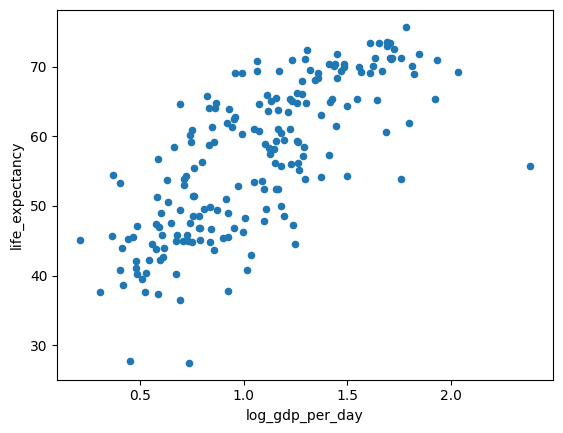

In [13]:
gapminder_by_year.loc[1960].plot.scatter('log_gdp_per_day', 'life_expectancy');

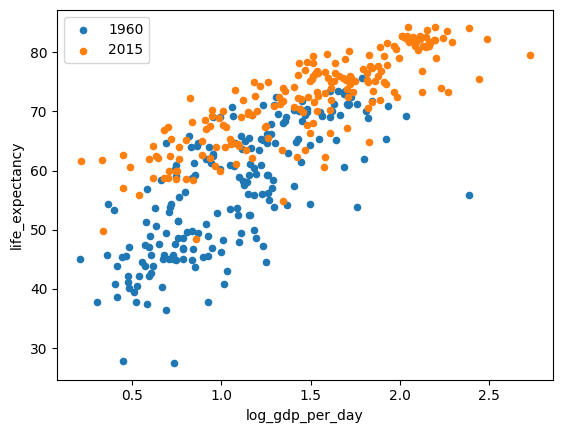

In [14]:
axes = gapminder_by_year.loc[1960].plot.scatter('log_gdp_per_day', 'life_expectancy', label=1960)
gapminder_by_year.loc[2015].plot.scatter('log_gdp_per_day', 'life_expectancy', label=2015, color='C1', ax=axes);

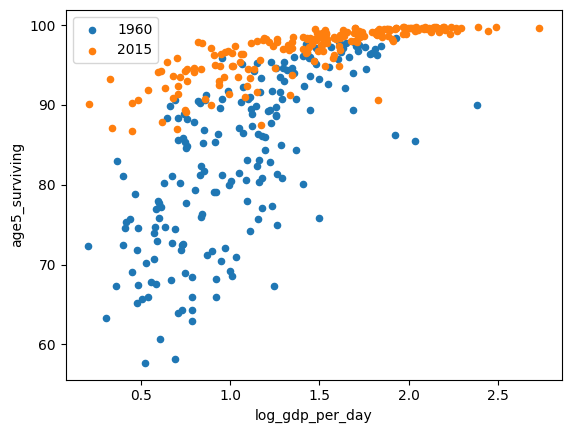

In [15]:

axes = gapminder_by_year.loc[1960].plot.scatter('log_gdp_per_day', 'age5_surviving', label=1960)
gapminder_by_year.loc[2015].plot.scatter('log_gdp_per_day', 'age5_surviving', label=2015, color='C1', ax=axes);

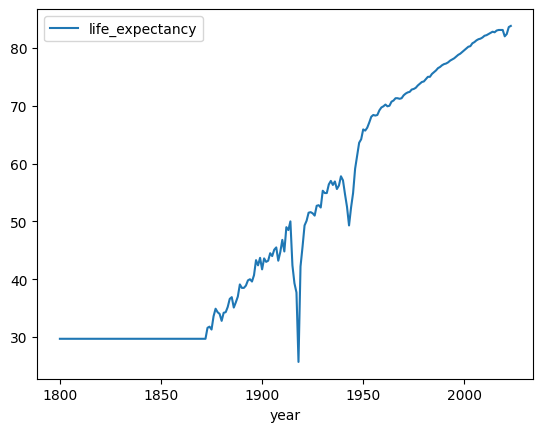

In [17]:
gapminder_by_country.loc['Italy'].sort_index().plot('year', 'life_expectancy');

Text(0, 0.5, 'life expectancy')

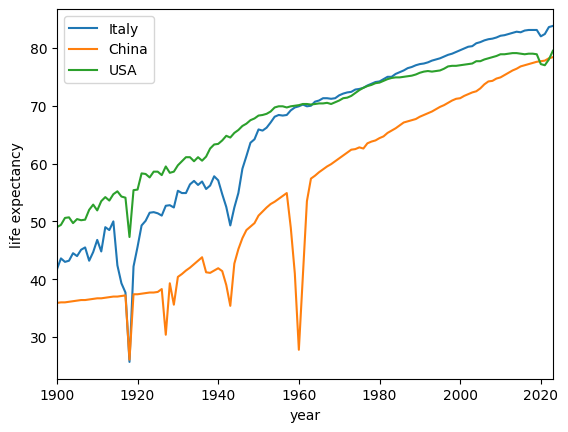

In [18]:
axes = gapminder_by_country.loc['Italy'].sort_values('year').plot('year', 'life_expectancy', label='Italy')
gapminder_by_country.loc['China'].sort_values('year').plot('year', 'life_expectancy', label='China', ax=axes)
gapminder_by_country.loc['USA'].sort_values('year').plot('year', 'life_expectancy', label='USA', ax=axes)

pp.axis(xmin=1900, xmax=2023)
pp.ylabel('life expectancy')

In [19]:
gapminder.babies_per_woman.mean()

5.242053225575057

In [20]:
gapminder.groupby('year').babies_per_woman.mean()

year
1800    6.041333
1801    5.963391
1802    5.966870
1803    5.908136
1804    6.027302
          ...   
2019    2.620205
2020    2.573538
2021    2.539897
2022    2.492359
2023    2.458308
Name: babies_per_woman, Length: 224, dtype: float64

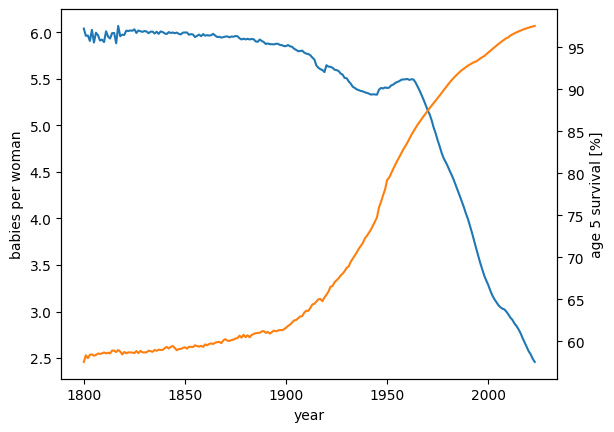

In [21]:
gapminder.groupby('year').babies_per_woman.mean().plot()
pp.ylabel('babies per woman')

gapminder.groupby('year').age5_surviving.mean().plot(secondary_y=True)
pp.ylabel('age 5 survival [%]');

In [22]:
gapminder.pivot_table('babies_per_woman', 'year', 'region')

region,Africa,America,Asia,Europe,Oceania
year,,,,,
1800,6.397593,6.041714,6.346600,5.148571,6.254286
1801,6.311923,6.052593,6.438889,5.032143,6.215714
1802,6.369286,6.035926,6.466471,4.977647,6.406250
1803,6.339286,6.034643,6.282917,5.046129,6.210000
1804,6.410938,6.025769,6.486333,5.111667,6.210000
...,...,...,...,...,...
2019,4.118889,1.926857,2.291400,1.535000,3.002857
2020,4.047778,1.879143,2.246800,1.517619,2.957857
2021,3.978333,1.846857,2.209400,1.530952,2.931429


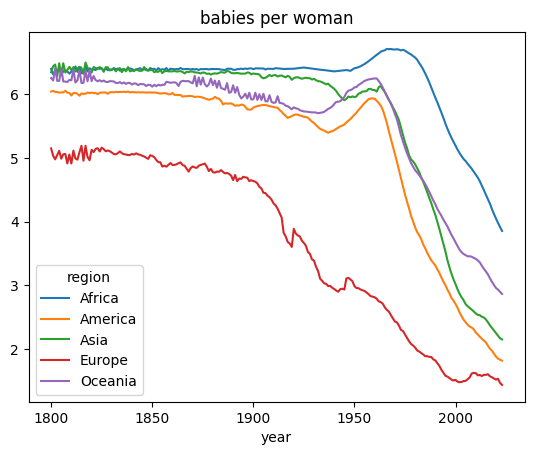

In [24]:
gapminder.pivot_table('babies_per_woman', 'year', 'region').plot()
pp.title('babies per woman');